<div style="background-color: #FFDDDD; font-size: 24px; font-weight: bold; padding-top: 10px;">SAMap for Human and Mouse Transcriptome Comparison</div>
<div style="background-color: #FFDDDD; font-size: 12px; padding-top: 15px;"><b>Author: </b>Coulter Ralston</div>
<div style="background-color: #FFDDDD; font-size: 12px; padding-top: 0px;"><b>Last Revised: </b>03-30-2026</div>

<div style="background-color: #D3D3D3; font-size: 18px; font-weight: bold; padding-top: 15px; padding-bottom: 10px;">Load Necessary Packages</div>

In [ ]:
#For SAM#
from samalg import SAM
from samalg.gui import SAMGUI #this is the interactive GUI

import pandas as pd

import scanpy as sc

In [1]:
#For SAMap#
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd

import scanpy as sc

<div style="background-color: #D3D3D3; font-size: 18px; font-weight: bold; padding-top: 15px; padding-bottom: 10px;">Load in and create SAM Objects </div>

In [ ]:
# Distal Human Samples (Fimbria) #

hD33 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Nikitin/Nikitin_D33/outs/filtered_feature_bc_matrix.h5')
hD34 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Nikitin/Nikitin_D34/outs/filtered_feature_bc_matrix.h5')
hD35 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Nikitin/Nikitin_D35/outs/filtered_feature_bc_matrix.h5')
hD36 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Nikitin/Nikitin_D36/outs/filtered_feature_bc_matrix.h5')
hD37 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Nikitin/Nikitin_D37/outs/filtered_feature_bc_matrix.h5')
hD38 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Nikitin/Nikitin_D38/outs/filtered_feature_bc_matrix.h5')
hFT1f = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Ulrich/Ulrich_FT1f/outs/filtered_feature_bc_matrix.h5')
hFT2f = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Ulrich/Ulrich_FT2f/outs/filtered_feature_bc_matrix.h5')
hFT3f = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Ulrich/Ulrich_FT3f/outs/filtered_feature_bc_matrix.h5')
hp6f = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Dinh/Dinh_p6f/outs/filtered_feature_bc_matrix.h5')
hp6i = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Dinh/Dinh_p6i/outs/filtered_feature_bc_matrix.h5')
hp7f = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Dinh/Dinh_p7f/outs/filtered_feature_bc_matrix.h5')
hp8 = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Dinh/Dinh_p8/outs/filtered_feature_bc_matrix.h5')
hD3F = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Lengyel_Aligned/D3F_aligned/outs/filtered_feature_bc_matrix.h5')
hD4F = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Lengyel_Aligned/D4F_aligned/outs/filtered_feature_bc_matrix.h5')
hD5F = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Lengyel_Aligned/D5F_aligned/outs/filtered_feature_bc_matrix.h5')
hD6F = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Lengyel_Aligned/D6F_aligned/outs/filtered_feature_bc_matrix.h5')
hD7F = sc.read_10x_h5('/workdir/cqr3/SAMap/cellranger_outs/Lengyel_Aligned/D7F_aligned/outs/filtered_feature_bc_matrix.h5')


In [ ]:
# Distal Human Samples make unique #
hD33.var_names_make_unique()
hD34.var_names_make_unique()
hD35.var_names_make_unique()
hD36.var_names_make_unique()
hD37.var_names_make_unique()
hD38.var_names_make_unique()
hFT1f.var_names_make_unique()
hFT2f.var_names_make_unique()
hFT3f.var_names_make_unique()
hp6f.var_names_make_unique()
hp6i.var_names_make_unique()
hp7f.var_names_make_unique()
hp8.var_names_make_unique()
hD3F.var_names_make_unique()
hD4F.var_names_make_unique()
hD5F.var_names_make_unique()
hD6F.var_names_make_unique()
hD7F.var_names_make_unique()

In [ ]:
# Check shape to avoid duplicate entries #
print(hD33.shape)
print(hD34.shape)
print(hD35.shape)
print(hD36.shape)
print(hD37.shape)
print(hD38.shape)
print(hFT1f.shape)
print(hFT2f.shape)
print(hFT3f.shape)
print(hp6f.shape)
print(hp6i.shape)
print(hp7f.shape)
print(hp8.shape)
print(hD3F.shape)
print(hD4F.shape)
print(hD5F.shape)
print(hD6F.shape)
print(hD7F.shape)

In [ ]:
# Add sample identifiers #

hD33.obs["sample"] = "hD33"
hD34.obs["sample"] = "hD34"
hD35.obs["sample"] = "hD35"
hD36.obs["sample"] = "hD36"
hD37.obs["sample"] = "hD35"
hD38.obs["sample"] = "hD38"
hFT1f.obs["sample"] = "hFT1f"
hFT2f.obs["sample"] = "hFT2f"
hFT3f.obs["sample"] = "hFT3f"
hp6f.obs["sample"] = "hp6f"
hp6i.obs["sample"] = "hp6i"
hp7f.obs["sample"] = "hp7f"
hp8.obs["sample"] = "hp8"
hD3F.obs["sample"] = "hD3F"
hD4F.obs["sample"] = "hD4F"
hD5F.obs["sample"] = "hD5F"
hD6F.obs["sample"] = "hD6F"
hD7F.obs["sample"] = "hD7F"


In [ ]:
# Combine into a larger object for QC #

samples = ["hD33", "hD34", "hD35", "hD36", "hD37", "hD38", "hFT1f", "hFT2f", "hFT3f", "hp6f", "hp6i", "hp7f", "hp8" , "hD3F" , "hD4F" , "hD5F" , "hD6F" , "hD7F"]
all_human = hD33.concatenate(hD34, hD35, hD36, hD37, hD38, hFT1f, hFT2f, hFT3f, hp6f, hp6i, hp7f, hp8, hD3F , hD4F , hD5F , hD6F , hD7F, batch_key= "sample", batch_categories=samples)

In [ ]:
all_human.obs_names_make_unique()
all_human.var_names_make_unique()

In [ ]:
all_human.var['MT'] = all_human.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(all_human, qc_vars=['MT'], percent_top=None, log1p=False, inplace=True)

In [ ]:
df = pd.read_csv('/workdir/cqr3/SAMap/cell_annotations/20250115_all_human_labels_for_SAMap.csv')

In [ ]:
df['Unnamed: 0'] = df['Unnamed: 0'].str[4:]

df['Unnamed: 0'] = df['Unnamed: 0'] + '-' + 'h' + df['FT_Named.meta.data.Sample']

df['FT_Named.meta.data.Sample'] = 'h' + df['FT_Named.meta.data.Sample']

df.rename(columns={'Unnamed: 0': 'Cells'}, inplace=True)

In [ ]:
df2 = all_human.obs

In [ ]:
df2['Cells'] = df2.index

In [ ]:
df3 = pd.merge(df, df2, how='inner', on='Cells') 

df3.set_index('Cells', inplace=True)
df3.drop('FT_Named.meta.data.Sample', axis=1, inplace=True)
df3.rename(columns={'FT_Named.active.ident': 'cluster_name'}, inplace=True)

In [ ]:
all_human_subset = all_human[all_human.obs['Cells'].isin(df3.index)]

In [ ]:
df3.index = df3.index.rename('idx')
df3['Cells'] = df3.index

In [ ]:

all_human_subset.obs = pd.merge(all_human_subset.obs, df3[['Cells', 'cluster_name']], on='Cells', how='left')

In [ ]:

all_human_subset.write('/workdir/cqr3/SAMap/raw_h5ad/20250115_human_filtered.h5ad')

In [ ]:
mD1 = sc.read_h5ad('/workdir/cqr3/SAMap/raw_h5ad/mouse/mD1.h5ad')
mD2 = sc.read_h5ad('/workdir/cqr3/SAMap/raw_h5ad/mouse/mD2.h5ad')
mD4 = sc.read_h5ad('/workdir/cqr3/SAMap/raw_h5ad/mouse/mD4.h5ad')

In [ ]:
samples = ["mD1", "mD2", "mD4"]
all_mouse = mD1.concatenate(mD2, mD4, batch_key= "sample", batch_categories=samples)

In [ ]:
all_mouse.obs_names_make_unique()
all_mouse.var_names_make_unique()

In [ ]:
# Fix Mouse MT genes #

mito_gene_list = ["TrnP","TrnT","CYTB","TrnE","ND6","ND5","TrnL2", "TrnS2","TrnH","ND4","ND4L","TrnR","ND3","TrnG",
                  "COX3","ATP6","ATP8","TrnK","COX2","TrnD","TrnS1", "COX1","TrnY","TrnC","TrnN","TrnA","TrnW",
                  "ND2","TrnM", "TrnQ","TrnI","ND1","TrnL1","mt-Rnr2","TrnV","mt-Rnr1","TrnF"] 

                  # Note: This is a list from ChrM from the Ref Genome (mm39)

new_mito_gene_list = ['mt-TrnP', 'mt-TrnT', 'mt-CYTB', 'mt-TrnE', 'mt-ND6', 'mt-ND5', 'mt-TrnL2', 'mt-TrnS2', 'mt-TrnH',
                  'mt-ND4', 'mt-ND4L', 'mt-TrnR', 'mt-ND3', 'mt-TrnG', 'mt-COX3', 'mt-ATP6', 'mt-ATP8', 'mt-TrnK',
                  'mt-COX2', 'mt-TrnD', 'mt-TrnS1', 'mt-COX1', 'mt-TrnY', 'mt-TrnC', 'mt-TrnN', 'mt-TrnA', 'mt-TrnW',
                  'mt-ND2', 'mt-TrnM', 'mt-TrnQ', 'mt-TrnI', 'mt-ND1', 'mt-TrnL1', 'mt-Rnr2', 'mt-TrnV',
                  'mt-Rnr1', 'mt-TrnF']
                  
                  # Note: This is a fixed list from ChrM from the Ref Genome (mm39)

In [ ]:
fixed = new_mito_gene_list + list(all_mouse.var_names[37:])

In [ ]:
all_mouse.var_names = fixed

In [ ]:
all_mouse.var['mt'] = all_mouse.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(all_mouse, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
df['Unnamed: 0'] = df['Unnamed: 0'].str[4:]

df['Unnamed: 0'] = df['Unnamed: 0'] + '-' + df['Distal_Named.meta.data.Sample']

df.rename(columns={'Unnamed: 0': 'Cells'}, inplace=True)

In [ ]:
df2 = all_mouse.obs

In [ ]:
df2['Cells'] = df2.index

In [ ]:
df3 = pd.merge(df, df2, how='inner', on='Cells') 

df3.set_index('Cells', inplace=True)
df3.drop('Distal_Named.meta.data.Sample', axis=1, inplace=True)
df3.rename(columns={'Distal_Named.active.ident': 'cluster_name'}, inplace=True)


In [ ]:
df3.index = df3.index.rename('idx')
df3['Cells'] = df3.index

In [ ]:
all_mouse_subset = all

In [ ]:
all_mouse_subset = all_mouse[all_mouse.obs['Cells'].isin(df3.index)]

In [ ]:
all_mouse_subset.obs = pd.merge(all_mouse_subset.obs, df3[['Cells', 'cluster_name']], on='Cells', how='left')

In [ ]:
all_mouse_subset.write('/workdir/cqr3/SAMap/raw_h5ad/20250115_mouse_filtered.h5ad')

In [ ]:
### Create SAM Objects ###

In [ ]:
mouse_sam.load_data('/workdir/cqr3/SAMap/raw_h5ad/20250115_mouse_filtered.h5ad')

In [ ]:
mouse_sam.preprocess_data()

In [ ]:
mouse_sam.run()

In [ ]:
mouse_sam.scatter()

In [ ]:
human_sam = SAM()

In [ ]:
human_sam.load_data('/workdir/cqr3/SAMap/raw_h5ad/20250115_human_filtered.h5ad')

In [ ]:
human_sam.preprocess_data()

In [ ]:
human_sam.run()

In [ ]:
human_sam.scatter()

In [ ]:
### Annotating Objects ###

In [ ]:
gui_obj = SAMGUI(mouse_sam)
gui_obj.SamPlot

In [ ]:
df2 = mouse_sam.adata.obs

In [ ]:
df2['Cells'] = df2.index

In [ ]:
df = pd.read_csv('/workdir/cqr3/SAMap/cell_annotations/20250115_all_mouse_labels_for_SAMap.csv')

In [ ]:
df['Unnamed: 0'] = df['Unnamed: 0'].str[4:]

df['Unnamed: 0'] = df['Unnamed: 0'] + '-' + df['Distal_Named.meta.data.Sample']

df.rename(columns={'Unnamed: 0': 'Cells'}, inplace=True)

In [ ]:
df3 = pd.merge(df, df2, how='outer', on='Cells') 

df3.set_index('Cells', inplace=True)
df3.drop('Distal_Named.meta.data.Sample', axis=1, inplace=True)
df3.rename(columns={'Distal_Named.active.ident': 'cluster_name'}, inplace=True)


In [ ]:
mouse_sam.adata.obs = df3

In [ ]:
mouse_sam.adata.obs.dropna(inplace=True)

In [ ]:
mouse_sam.save_anndata('/workdir/cqr3/SAMap/raw_h5ad/20250115_mouse_sam_annotated.h5ad')

In [ ]:
df = pd.read_csv('/workdir/cqr3/SAMap/cell_annotations/20250115_all_human_labels_for_SAMap.csv')

In [ ]:
df2 = human_sam.adata.obs

In [ ]:
df['Unnamed: 0'] = df['Unnamed: 0'].str[4:]

df['Unnamed: 0'] = df['Unnamed: 0'] + '-' + 'h' + df['FT_Named.meta.data.Sample']

df['FT_Named.meta.data.Sample'] = 'h' + df['FT_Named.meta.data.Sample']

df.rename(columns={'Unnamed: 0': 'Cells'}, inplace=True)

In [ ]:
df2['Cells'] = df2.index

In [ ]:
df3 = pd.merge(df, df2, how='inner', on='Cells') 

df3.set_index('Cells', inplace=True)
df3.drop('FT_Named.meta.data.Sample', axis=1, inplace=True)
df3.rename(columns={'FT_Named.active.ident': 'cluster_name'}, inplace=True)


In [ ]:
df3 = pd.merge(df, df2, how='inner', on='Cells') 

In [ ]:
human_sam.adata.obs = pd.merge(human_sam.adata.obs, df3, how='outer', on='Cells') 

In [ ]:
human_sam.adata.obs.dropna(inplace=True)

In [ ]:
human_sam.adata.obs.drop(['sample_y','n_genes_y','n_genes_by_counts_y','total_counts_y','total_counts_MT_y','pct_counts_MT_y'], axis=1, inplace=True)

In [ ]:
human_sam.save_anndata('/workdir/cqr3/SAMap/raw_h5ad/20250115_human_sam_annotated.h5ad')

<div style="background-color: #D3D3D3; font-size: 18px; font-weight: bold; padding-top: 15px; padding-bottom: 10px;">Load in SAMs and Build SAMap Object</div>

In [2]:

A=pd.read_csv('/workdir/cqr3/SAMap/gene_maps/mohu/mo_to_hu.txt', sep='\t', index_col=0)
B=pd.read_csv('/workdir/cqr3/SAMap/gene_maps/mohu/hu_to_mo.txt',sep='\t',index_col=0)

A.head()


,1,2,3,4,5,6,7,8,9,10,11
0,,,,,,,,,,,
Gm26206,RNU6-40P,78.571,28,6,0,84,1,84,1,7.120000e-11,64.8
Gm26206,RNU6-86P,85.714,28,4,0,84,1,84,1,9.780000e-11,64.3
Gm26206,RNU6-1209P,85.714,28,4,0,84,1,84,1,9.780000e-11,64.3
Gm26206,RNU6-188P,78.571,28,6,0,84,1,84,1,1.340000e-10,63.8
Gm26206,RNU6-480P,82.143,28,5,0,84,1,84,1,1.340000e-10,63.8


In [3]:
hu = '/workdir/cqr3/SAMap/raw_h5ad/20250115_human_sam_annotated.h5ad'
mo = '/workdir/cqr3/SAMap/raw_h5ad/20250115_mouse_sam_annotated.h5ad'

In [4]:
filenames = {'hu':hu,'mo':mo}

In [7]:
sam1=SAM()
sam1.load_data(hu)

sam2=SAM()
sam2.load_data(mo)

In [9]:
sam2.adata.var

,gene_ids,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mask_genes,means,variances,weights,spatial_dispersions
mt-TrnP,TrnP,True,42,0.002253,99.767455,40.693851,True,0.000950,0.001360,0.081081,0.006994
mt-TrnT,TrnT,True,61,0.003347,99.662256,60.453079,True,0.001177,0.002162,0.087914,0.008223
mt-CYTB,CYTB,True,15749,22.487629,12.801063,406151.500000,True,3.574668,2.562252,0.686747,0.501752
mt-TrnE,TrnE,True,28,0.001506,99.844970,27.203865,True,0.001032,0.001538,0.085722,0.007818
mt-ND6,ND6,True,933,0.054662,94.834173,987.246582,True,0.014665,0.020135,0.168900,0.030350
...,...,...,...,...,...,...,...,...,...,...,...
Gm7341,Gm7341,False,0,0.000000,100.000000,0.000000,False,0.000000,0.000000,0.000000,0.000000
LOC118567655,LOC118567655,False,99,0.005948,99.451858,107.425537,True,0.002871,0.004247,0.106400,0.012044
Gm18956,Gm18956,False,0,0.000000,100.000000,0.000000,False,0.000000,0.000000,0.000000,0.000000
Xkr4,Xkr4,False,891,0.073269,95.066718,1323.319702,True,0.026166,0.042068,0.236447,0.059479


In [8]:
sam1.adata.var

,gene_ids,feature_types,genome,MT,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mask_genes,means,variances,weights,spatial_dispersions
ATAD3B,ENSG00000160072,Gene Expression,CQR_human_ref,False,5202,0.046704,95.707567,5660.0,True,0.019562,0.026716,0.192932,0.034900
DDX11L17,ENSG00000279928,Gene Expression,CQR_human_ref,False,1,0.000008,99.999175,1.0,True,0.000000,0.000000,0.000000,0.000000
ENSG00000228037,ENSG00000228037,Gene Expression,CQR_human_ref,False,237,0.001972,99.804439,239.0,True,0.000586,0.000759,0.074630,0.005222
PRDM16,ENSG00000142611,Gene Expression,CQR_human_ref,False,3174,0.035622,97.380972,4317.0,True,0.008524,0.012310,0.207431,0.040342
ENSG00000284616,ENSG00000284616,Gene Expression,CQR_human_ref,False,4,0.000033,99.996699,4.0,True,0.000034,0.000039,0.038769,0.001409
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,ENSG00000271254,Gene Expression,CQR_human_ref,False,2127,0.019515,98.244905,2365.0,True,0.002590,0.003412,0.116830,0.012797
U1-4,ENSG00000275987,Gene Expression,CQR_human_ref,False,11,0.000099,99.990923,12.0,True,0.000069,0.000117,0.053290,0.002663
ENSG00000268674,ENSG00000268674,Gene Expression,CQR_human_ref,False,3,0.000025,99.997525,3.0,True,0.000000,0.000000,0.000000,0.000000
ENSG00000277475,ENSG00000277475,Gene Expression,CQR_human_ref,False,1,0.000008,99.999175,1.0,False,0.000000,0.000000,0.000000,0.000000


In [17]:
sams = {'hu':sam1,'mo':sam2}

sm = SAMAP(sams,
          f_maps = '/workdir/cqr3/SAMap/gene_maps/')

Not updating the manifold...
Not updating the manifold...
44714 `hu` gene symbols match between the datasets and the BLAST graph.
31727 `mo` gene symbols match between the datasets and the BLAST graph.


In [18]:
sm.run(pairwise=True)
samap = sm.samap # SAM object with mouse and human species stitched together

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 122.60115456581116
Correcting data with means. 173.50550746917725
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mo...
Indegree coarsening
0/5 (0, 85342)
1/5 (20000, 85342)
2/5 (40000, 85342)
3/5 (60000, 85342)
4/5 (80000, 85342)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/home/cqr3/miniconda3/envs/cqr3_py/lib/python3.10/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Iteration 1 complete.
Alignment scores:
          hu        mo
hu  0.000000  0.554808
mo  0.718366  0.000000
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 85.78344511985779
Correcting data with means. 131.7847125530243
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mo...
Indegree coarsening
0/5 (0, 85342)
1/5 (20000, 85342)
2/5 (40000, 85342)
3/5 (60000, 85342)
4/5 (80000, 85342)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/home/cqr3/miniconda3/envs/cqr3_py/lib/python3.10/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Iteration 2 complete.
Alignment scores:
          hu        mo
hu  0.000000  0.637907
mo  0.786926  0.000000
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 85.4810836315155
Correcting data with means. 137.85247349739075
Expanding neighbourhoods of species hu...
Expanding neighbourhoods of species mo...
Indegree coarsening
0/5 (0, 85342)
1/5 (20000, 85342)
2/5 (40000, 85342)
3/5 (60000, 85342)
4/5 (80000, 85342)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/home/cqr3/miniconda3/envs/cqr3_py/lib/python3.10/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Iteration 3 complete.
Alignment scores:
          hu        mo
hu  0.000000  0.644309
mo  0.787643  0.000000
Running UMAP on the stitched manifolds.
Elapsed time: 31.176619482040405 minutes.


In [2]:
from samap.utils import load_samap , save_samap

In [20]:
save_samap(sm , '/workdir/cqr3/SAMap/20250116_UT_SAMap_Object.pkl')

In [ ]:
## Skip Preprocessing ##

In [2]:
from samap.utils import load_samap , save_samap

In [3]:
sm = load_samap('/workdir/cqr3/SAMap/20250116_UT_SAMap_Object.pkl')

In [4]:
UT_samap = sm.samap

<div style="background-color: #D3D3D3; font-size: 18px; font-weight: bold; padding-top: 15px; padding-bottom: 10px;">SAMap Data Visualization</div>

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

<div style="background-color: #FFD3D3; font-size: 14px; font-weight: bold; padding-top: 8px; padding-bottom: 8px;">FIGURE 1E</div>

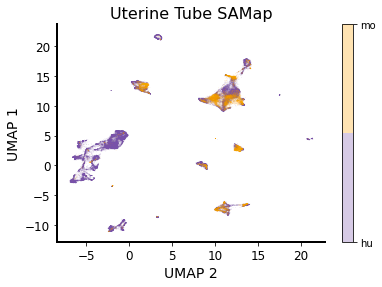

In [9]:

colors = ['#7851a9','#FFA500']

cmap = mcolors.ListedColormap(colors)



UT_samap.scatter(c = "species",cmap=cmap,s=0.3,alpha=0.3)

# Set the x and y axis labels
plt.xlabel('UMAP 2',fontsize=14)
plt.ylabel('UMAP 1',fontsize=14)

# Set the plot title
plt.title('Uterine Tube SAMap',fontsize=16)

# Customize the x-axis and y-axis
ax = plt.gca()  # Get the current axes object
ax.spines['bottom'].set_linewidth(2.0)  # Set the bottom spine thickness
ax.spines['left'].set_linewidth(2.0)  # Set the left spine thickness
ax.spines['top'].set_visible(False)  # Hide the top spine
ax.spines['right'].set_visible(False)  # Hide the right spine
ax.grid(False)  # Disable gridlines

# Customize the axes tick labels
ax.tick_params(labelsize=12, colors='black')

# Show the plot

#plt.savefig('20250116_UT_SAMap.eps', format='eps')
plt.savefig("20260311_UT_SAMap.svg", format="svg",transparent=True)

plt.show()